# **Assignment 1: Demand prediction of bike sharing system**

Bike sharing services are nowadays spread all over the world. They are beneficial for cities as they offer a climate neutral and healthy way of transportation. Moreover, similar to e-scooters, for the companies and transportation researchers they generate valuable data. This includes the trip route, trip origins and destinations, duration, and much more.

In this assignment we use a public bike sharing dataset from Washington, D.C., USA. published by Fanaee-T, H. (2013). Bike Sharing [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5W894.

## Your Task

Your task in this assignment is:

1) to predict the demand of hourly rentals (**target-column: cnt**) using the [XGBoost](https://xgboost.readthedocs.io/en/stable/) and linear regression model. In this notebook we have provided you with the basic structure how to approach the problem. Feel free to reuse and improve parts of the exercise material.

2) After you have created the model please upload your code to Github and post the link to the notebook in the corresponding forum for the assignment with a short text describing how you have solved the task.

## Load data

You can also find more information about the data and the columns at: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [54]:
# importing all
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
from sklearn.linear_model import LinearRegression

In [55]:
url = 'https://raw.githubusercontent.com/zhenliangma/Applied-AI-in-Transportation/master/Exercise_2_regression_model/Exercise2BikeSharing.csv'
df = pd.read_csv(url)

#df = pd.read_csv('Exercise2BikeSharing.csv')
df.head(10)

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
5,6,2011-01-01,1,0,1,5,0,6,0,2,0.24,0.2576,0.75,0.0896,0,1,1
6,7,2011-01-01,1,0,1,6,0,6,0,1,0.22,0.2727,0.80,0.0000,2,0,2
7,8,2011-01-01,1,0,1,7,0,6,0,1,0.20,0.2576,0.86,0.0000,1,2,3
8,9,2011-01-01,1,0,1,8,0,6,0,1,0.24,0.2879,0.75,0.0000,1,7,8
9,10,2011-01-01,1,0,1,9,0,6,0,1,0.32,0.3485,0.76,0.0000,8,6,14


In [56]:
df.shape

(17379, 17)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


## Train / Test split
- Target: `cnt` (count of total rental bikes including both casual and registered)
- Predictors: weather (`temp`, `atemp`, `hum`, `windspeed`, `weathersit`), calendar (`hr`, `weekday`, `workingday`, `holiday`, `season`), and `yr`.
- We keep it simple; you can expand features (e.g., interactions) later.

**In the cell I take the df and split it into a training set, consisting of 20% of the actual df.**

In [58]:
target = 'cnt'

X = df.copy()
y = df[target].astype(float)

X.drop(columns=[target], inplace=True)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Data Processing / Feature Engineering

Before training the model think about data processing and feature engineering steps if applicable, such as:
- adding/removal of features
- normalization
- one hot encoding
- ...


Here i look at the correlation values for each featsure and the target "cnt".
Note that I have already here decided that some features are not of interest and are not included in the correlation matrix. More on that furtehr down the code.

In [59]:
corr_vars = [
    'season',
    'yr',
    'mnth',
    'hr',
    'holiday',
    'weekday',
    'workingday',
    'weathersit',
    'temp',
    'atemp',
    'hum',
    'windspeed',
    'cnt'
]

corr_matrix = df[corr_vars].corr()

corr_with_cnt = (
    df[corr_vars]
    .corr()['cnt']
    .sort_values(ascending=False)
)

print(corr_with_cnt)

cnt           1.000000
temp          0.404772
atemp         0.400929
hr            0.394071
yr            0.250495
season        0.178056
mnth          0.120638
windspeed     0.093234
workingday    0.030284
weekday       0.026900
holiday      -0.030927
weathersit   -0.142426
hum          -0.322911
Name: cnt, dtype: float64


In the table obove we see the correlation values of each featsure. A number close to +1 means that as one variable goes up, the other variable goes up. And a coefficent close to -1 to means that as one variable goes up, the other variable goes down.

The correlation of all varibles are shown in the matrix below.

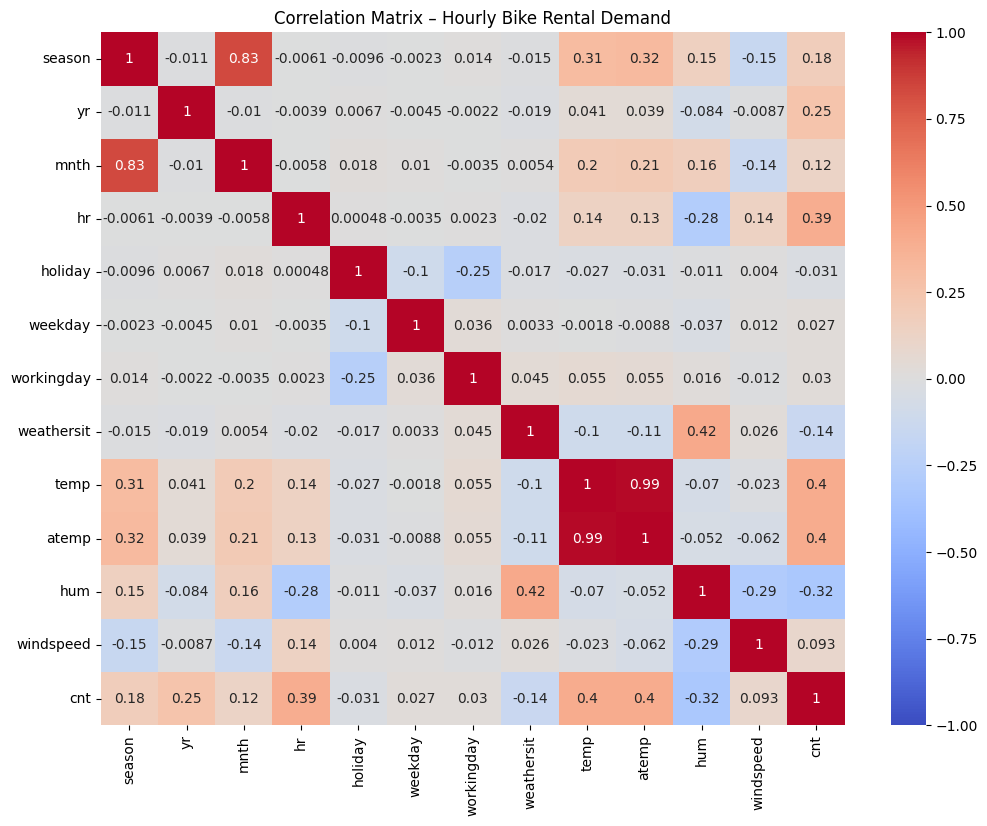

In [60]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0
)

plt.title('Correlation Matrix – Hourly Bike Rental Demand')
plt.show()

Here is a pairplot to further illustrate a correlation.

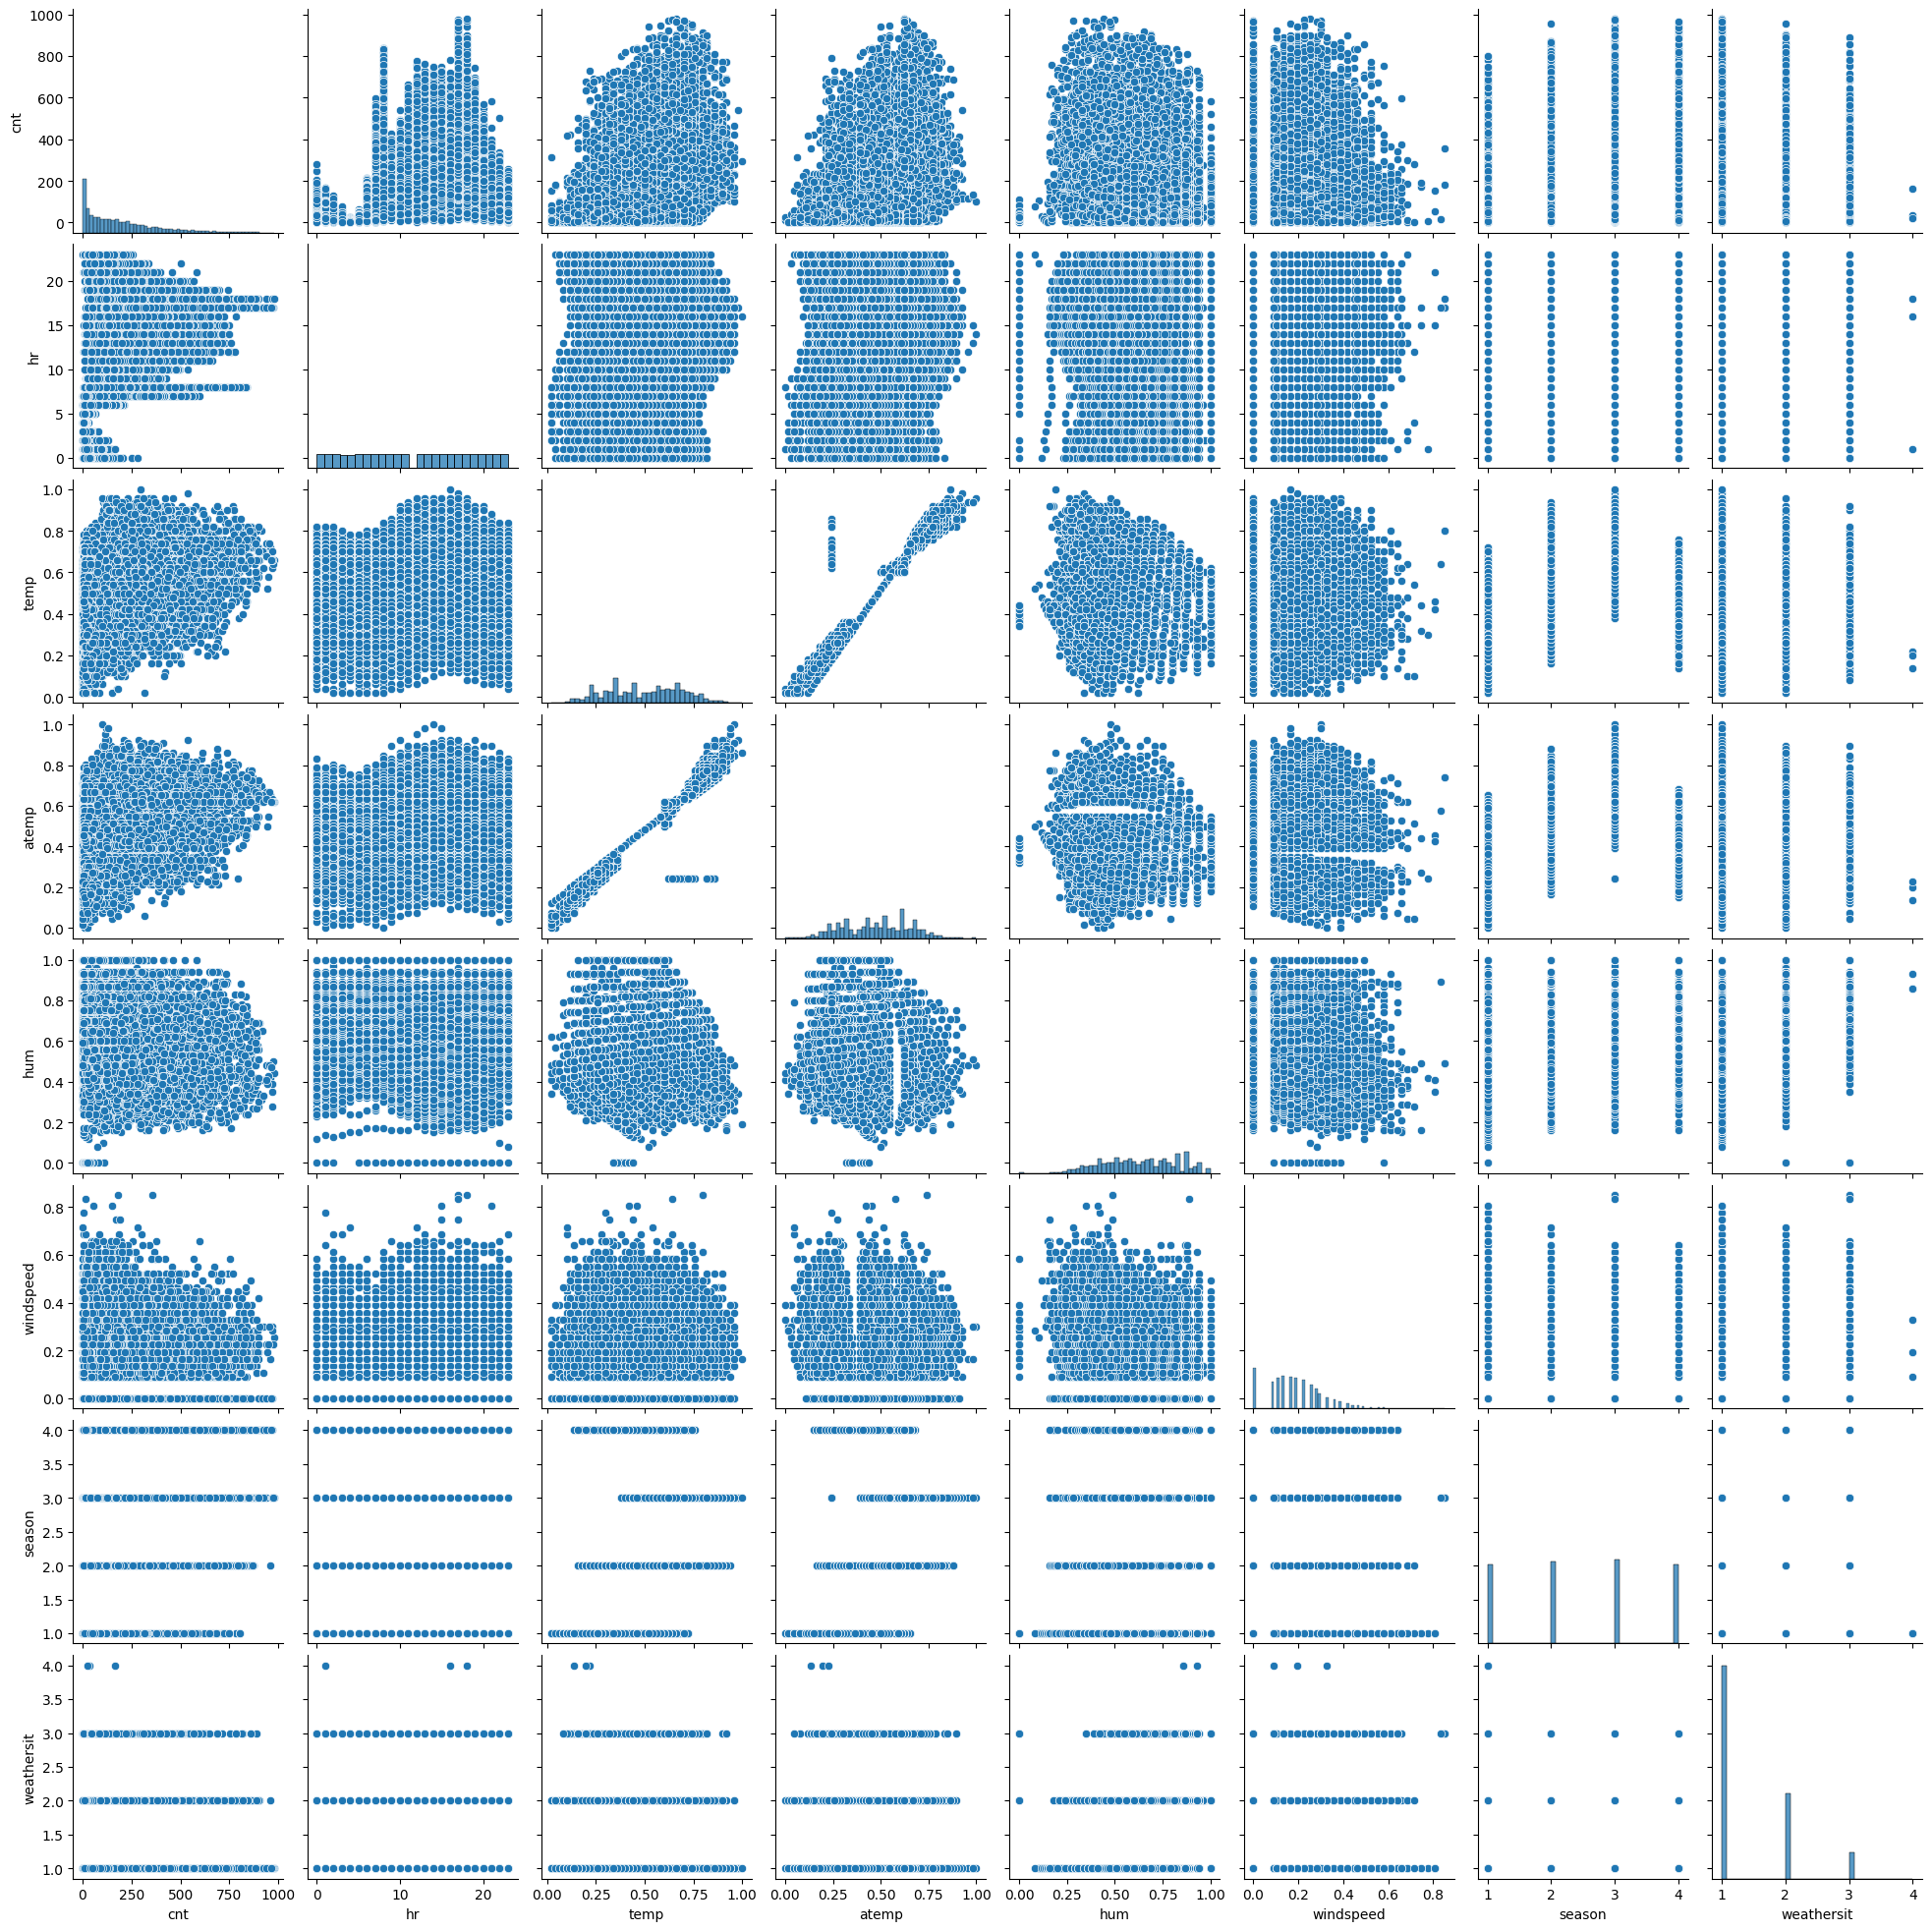

In [61]:
pairplot_vars = [
    'cnt',
    'hr',
    'temp',
    'atemp',
    'hum',
    'windspeed',
    'season',
    'weathersit'
]

sns.pairplot(
    df[pairplot_vars],
    diag_kind='hist'
)

plt.show()

TO see the correlation for the "cnt" closer, I did a figure showing only that row.

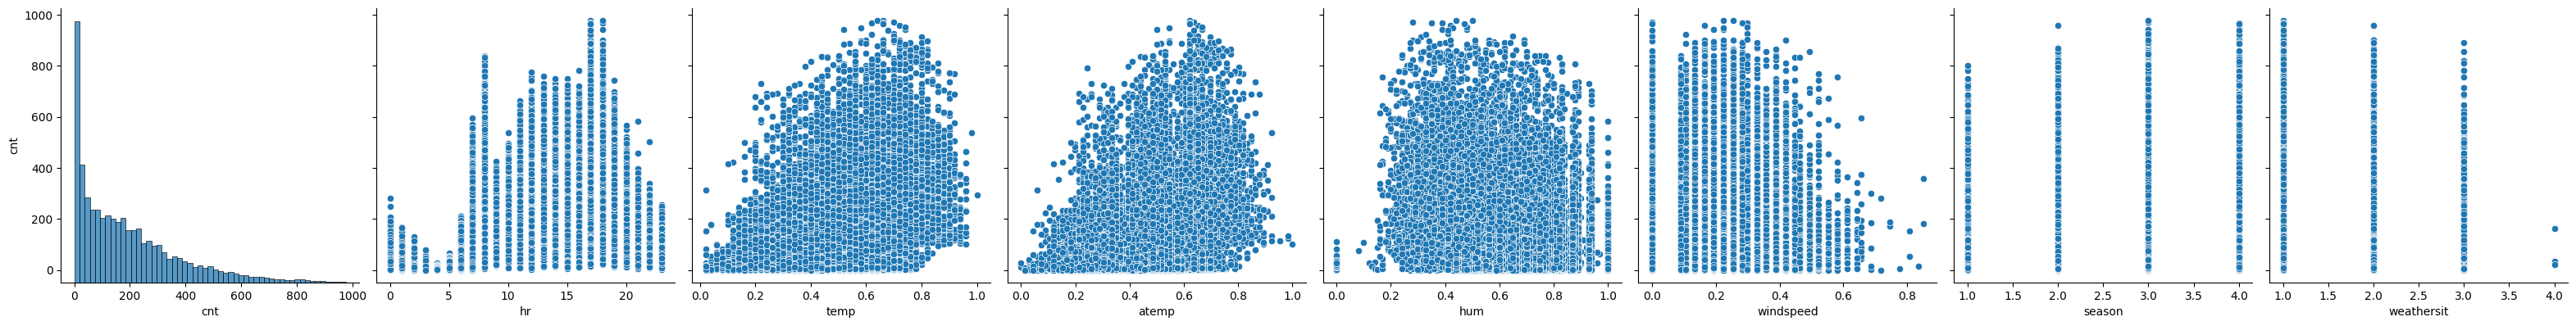

In [62]:
sns.pairplot(
    df,
    x_vars=df[pairplot_vars],
    y_vars='cnt',
    height=4,
    aspect=1
)

plt.show()

Now for the features being removed.

Instant was removed since it is only an ID and not relevent.

dtday was removed since time of day is not relevant this time.

casual and registred were removed since they make up cnt and there was a risk of data leakage if they remained.

In [63]:
# Remove features that are  not  used for prediction
X_train = X_train.drop(columns=['instant', 'dteday', 'casual', 'registered', 'atemp'])
X_test = X_test.drop(columns=['instant', 'dteday', 'casual', 'registered', 'atemp'])

Here the remaining features are split into categorical and numberical featsures to uese later for scaling and one hot encodeing

In [64]:
categorical_features = [
    'season',
    'mnth',
    'hr',
    'weekday',
    'weathersit'
]

numerical_features = [
    'temp',
    'hum',
    'windspeed'
]

binary_features = [
    'yr',
    'holiday',
    'workingday'
]

below are rge numerical values before scaling

In [65]:
print("Before scaling:")
print(X_train[numerical_features].head())

Before scaling:
      temp   hum  windspeed
335   0.20  0.55     0.2239
7035  0.52  0.42     0.1045
8051  0.46  1.00     0.2239
2133  0.46  0.31     0.0000
8485  0.20  0.75     0.1045


In [67]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # uses standard scaler
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features) # One-hot encoding prevents the model from assuming an ordinal relationship between categorical values
    ],
    remainder='passthrough' # the rest biniary values remain the same
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

below we can see the numerical values after scaling, the std and mean as well as features created by the one hot encoding

In [68]:
scaled_numeric = preprocessor.named_transformers_['num'].transform(
    X_train[numerical_features]
)

scaled_numeric_df = pd.DataFrame(
    scaled_numeric,
    columns=numerical_features
)

print("After scaling:")
print(scaled_numeric_df.head())

print(scaled_numeric_df.describe().loc[['mean', 'std']].round(3))

After scaling:
       temp       hum  windspeed
0 -1.540837 -0.399449   0.278669
1  0.117112 -1.073743  -0.697714
2 -0.193753  1.934646   0.278669
3 -0.193753 -1.644299  -1.552252
4 -1.540837  0.637926  -0.697714
      temp  hum  windspeed
mean   0.0 -0.0       -0.0
std    1.0  1.0        1.0


In [69]:
feature_names = preprocessor.get_feature_names_out()

print("Number of features after preprocessing:")
print(len(feature_names))

print("\nFeature names:")
print(feature_names)

Number of features after preprocessing:
57

Feature names:
['num__temp' 'num__hum' 'num__windspeed' 'cat__season_1' 'cat__season_2'
 'cat__season_3' 'cat__season_4' 'cat__mnth_1' 'cat__mnth_2' 'cat__mnth_3'
 'cat__mnth_4' 'cat__mnth_5' 'cat__mnth_6' 'cat__mnth_7' 'cat__mnth_8'
 'cat__mnth_9' 'cat__mnth_10' 'cat__mnth_11' 'cat__mnth_12' 'cat__hr_0'
 'cat__hr_1' 'cat__hr_2' 'cat__hr_3' 'cat__hr_4' 'cat__hr_5' 'cat__hr_6'
 'cat__hr_7' 'cat__hr_8' 'cat__hr_9' 'cat__hr_10' 'cat__hr_11'
 'cat__hr_12' 'cat__hr_13' 'cat__hr_14' 'cat__hr_15' 'cat__hr_16'
 'cat__hr_17' 'cat__hr_18' 'cat__hr_19' 'cat__hr_20' 'cat__hr_21'
 'cat__hr_22' 'cat__hr_23' 'cat__weekday_0' 'cat__weekday_1'
 'cat__weekday_2' 'cat__weekday_3' 'cat__weekday_4' 'cat__weekday_5'
 'cat__weekday_6' 'cat__weathersit_1' 'cat__weathersit_2'
 'cat__weathersit_3' 'cat__weathersit_4' 'remainder__yr'
 'remainder__holiday' 'remainder__workingday']


# XGBoost

## Hyperparameter optimization
Hyperparameter tuning helps find the best set of hyperparameters for your model. Use Grid Search or Random Search with Cross Validation from scikit-learn to search for the best combination of parameters.

In [70]:
# Define a parameter grid for hyperparameter tuning
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]
}

# Create the GridSearchCV object
grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid,
    cv=5,
    verbose=2,
    scoring='neg_root_mean_squared_error'
)

# Fit the grid search to the processed training data
grid_search.fit(X_train_processed, y_train)

# Get the best parameters
best_params = grid_search.best_params_

print("Best Parameters:", best_params)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=100; total time=   0.1s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=3, n_estimators=200; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=5, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.05, max_depth=5, n_es

## Train the XGBoost and Linear regression models
Now, create an XGBoost and linear regression model using the best parameters and train them using the training data.

In [71]:
# XGBoost
best_xgb_model = grid_search.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test_processed)


In [72]:
# linear model

lr_model = LinearRegression()

lr_model.fit(X_train_processed, y_train)

y_pred_lr = lr_model.predict(X_test_processed)

# Comparing the two models

## Make predictions
Use the trained models to make predictions on the test data and compare the performance of the XGBoost and linear regression models using metrics like Mean Squared Error (MSE) and R-squared.

In [73]:
# XGBoost
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)



# Linear Regression
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("XGBoost")
print("RMSE:", rmse_xgb)
print("MAE:", mae_xgb)
print("R²:", r2_xgb)

print("\nLinear Regression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R²:", r2_lr)

XGBoost
RMSE: 44.594588951856494
MAE: 28.27262279609276
R²: 0.9371971725661603

Linear Regression
RMSE: 100.50203567020645
MAE: 74.095359408532
R²: 0.6810191705223025


## Visualize the predictions and compare the mdoels
Create a "Actual vs. Predicted Values" graph to give a visual inspection of the prediction quality.

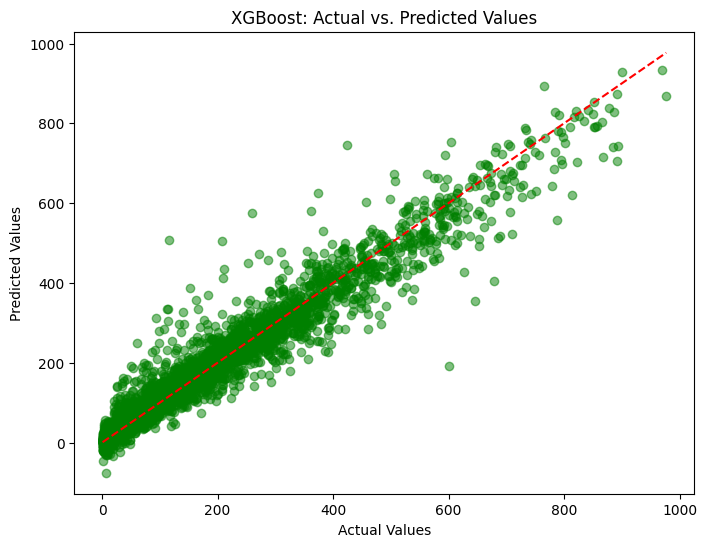

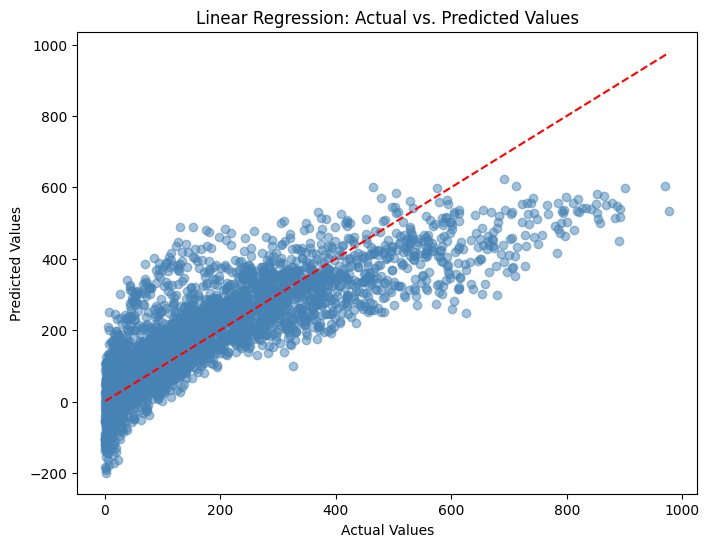

In [74]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_xgb, alpha=0.5, color='green')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--', color='red'
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('XGBoost: Actual vs. Predicted Values')

plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_lr, alpha=0.5, color='steelblue')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--' , color='red'
)

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Linear Regression: Actual vs. Predicted Values')

plt.show()

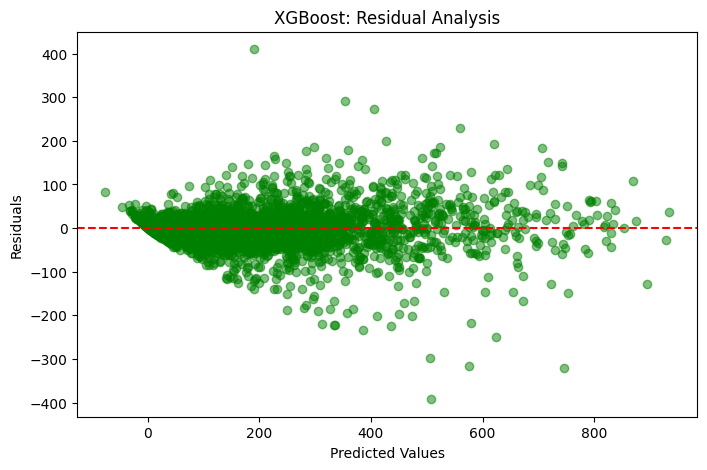

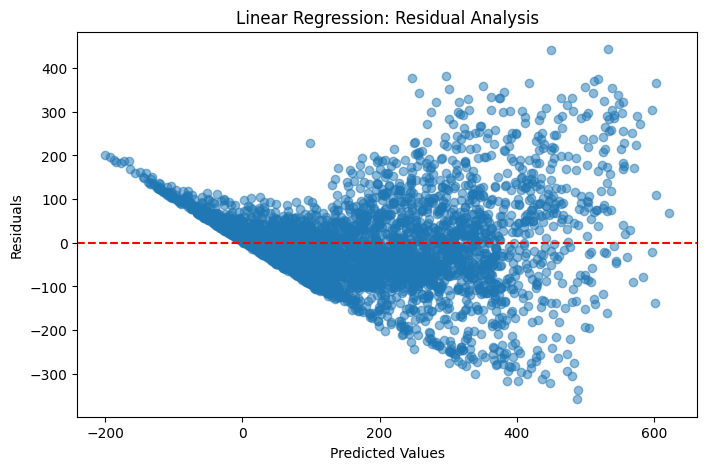

In [75]:
residuals_xgb = y_test - y_pred_xgb
residuals_lr = y_test - y_pred_lr

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_xgb, residuals_xgb, alpha=0.5, color='green')
plt.axhline(y=0, linestyle='--', color='red')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('XGBoost: Residual Analysis')
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.5)
plt.axhline(y=0, linestyle='--', color='red')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Linear Regression: Residual Analysis')
plt.show()